<center><img src="https://github.com/hse-ds/iad-applied-ds/blob/master/2021/hw/hw1/img/logo_hse.png?raw=1" width="1000"></center>

<h1><center>Прикладные задачи анализа данных</center></h1>
<h2><center>Домашнее задание 3: Прогнозирование временных рядов</center></h2>

# Введение

В этом задании Вам предстоит разобраться с основами анализа и прогнозирования временных рядов. 


![image](https://imgs.xkcd.com/comics/extrapolating.png)

In [1]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import display
from orbit.diagnostics.plot import plot_predicted_data
from orbit.models.dlt import DLT
from orbit.models.ktr import KTR
from orbit.models.lgt import LGT
from prophet import Prophet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_squared_log_error, r2_score)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sktime.forecasting.arima import ARIMA, AutoARIMA
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.naive import NaiveForecaster
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf

warnings.filterwarnings("ignore")


/home/seara/.pyenv/versions/3.6.5/envs/iad2/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ERROR:prophet.plot:Importing plotly failed. Interactive plots will not work.


## Задание 1 (1 балл). Поиск и предобработка данных.

В этом задании Вам необходимо _самостоятельно_ найти два временных ряда: один должен обладать месячной частотой, а второй — дневной.

Мы советуем поискать соответствующие временные ряды на платформе [kaggle](https://www.kaggle.com/datasets) или же взять один из [популярных](https://medium.com/analytics-vidhya/10-time-series-datasets-for-practice-d14fec9f21bc) временных рядов для анализа. 

**Не рекомендуется** использовать в качестве временных рядов цены финансовых инструментов в силу плохой предсказуемости изменения цен. **Запрещается** использовать готовые наборы данных из библиотек для анализа временных рядов, например, `from orbit.utils.dataset import load_iclaims`.

![bitcoin](https://avatars.mds.yandex.net/get-zen_doc/3417386/pub_6017dd4b8d30cb1780864ae0_6017f4aa8d30cb1780bf66ce/scale_1200)




В качестве отчета по заданию:

* Опишите источники временных рядов (ссылки на страницы скачивания). В случае, если данные требовали дополнительной обработки, приведите код этой обработки, загрузите данные в личное облачное хранилище и приведите ссылку на скачивание. Процесс получения временных рядов должен быть **четко** расписан и полностью **воспроизводиться**. 

* Приведите код считывания временных рядов из файлов и разделения на train/test. Соотношение размеров train/test на Ваше усмотрение, но мы советуем Вам выбрать 80% на 20%, если в test остаётся хотя бы пара лет наблюдений.



In [2]:
# скачаем данные
# !wget https://raw.githubusercontent.com/rishabh89007/Time_Series_Datasets/main/Brent%20Spot%20Price.csv
# !wget https://raw.githubusercontent.com/rishabh89007/Time_Series_Datasets/main/Nuclear%20Capacity.csv


In [3]:
# скачал 2 датасета из предложенных по ссылке https://medium.com/analytics-vidhya/10-time-series-datasets-for-practice-d14fec9f21bc
# Привел время к нужному формату DateTime и установил время в качестве индекса
ts1 = pd.read_csv(
    "Brent Spot Price.csv", sep=",", names=["Time", "Dollars"], skiprows=1
)
ts2 = pd.read_csv(
    "Nuclear Capacity.csv", sep=",", names=["Time", "Megawatts"], skiprows=1
)
ts1["Time"] = pd.to_datetime(ts1["Time"])
ts2["Time"] = pd.to_datetime(ts2["Time"].apply(lambda x: x[:-3]), format="%Y %m%d")
ts1.set_index("Time", inplace=True)
ts2.set_index("Time", inplace=True)
ts1 = ts1.sort_index()
ts2 = ts2.sort_index()


In [4]:
ts1.head()


,Dollars
Time,
1990-01-01,21.251
1990-02-01,19.813
1990-03-01,18.387
1990-04-01,16.612
1990-05-01,16.352


In [5]:
ts2.head()


,Megawatts
Time,
2007-01-01,101764.9
2007-01-02,101764.9
2007-01-03,101764.9
2007-01-04,101764.9
2007-01-05,101764.9


In [6]:
# сделаем разбиение на train/test
ts1_train_size = int(0.8 * ts1.shape[0])
ts2_train_size = int(0.8 * ts2.shape[0])


In [7]:
ts1_train = ts1[:ts1_train_size]
ts1_test = ts1[ts1_train_size:]
ts2_train = ts2[:ts2_train_size]
ts2_test = ts2[ts2_train_size:]


## Задание 2. Анализ временных рядов (1 балл).

* Отрисуйте временные ряды и визуально сделайте различимым разбиение на выборки — либо вертикальной чертой, либо разными цветами.

* Постройте графики [автокорреляционных функций](https://www.machinelearningmastery.ru/time-series-in-python-exponential-smoothing-and-arima-processes-2c67f2a52788/) для выбранных временных рядов. Прокомментируйте их: являются ли временные ряды сезонными? Видна ли на графиках длина сезонной составляющей ряда?

* В случае присутствия сезонности, разбейте временной ряд на повторяющиеся фрагменты и нарисуйте их наложенными для иллюстрации этой сезонности.

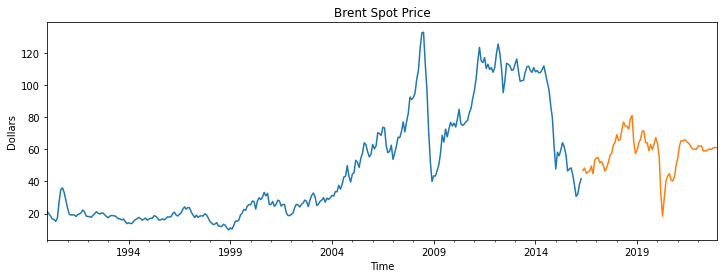

In [8]:
plt.figure(figsize=(12, 4))
ts1_train["Dollars"].plot()
ts1_test["Dollars"].plot()
plt.xlabel("Time")
plt.ylabel("Dollars")
plt.title("Brent Spot Price")
plt.show()


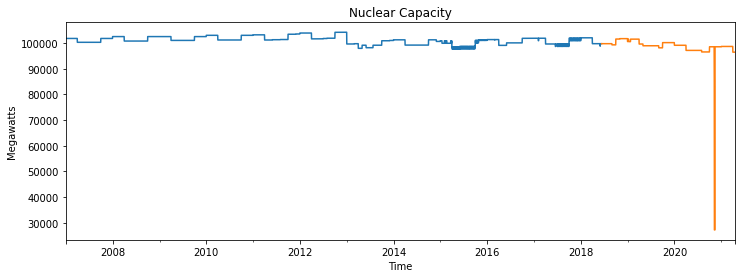

In [9]:
# отрисуем временные ряды
plt.figure(figsize=(12, 4))
ts2_train["Megawatts"].plot()
ts2_test["Megawatts"].plot()
plt.xlabel("Time")
plt.ylabel("Megawatts")
plt.title("Nuclear Capacity")
plt.show()


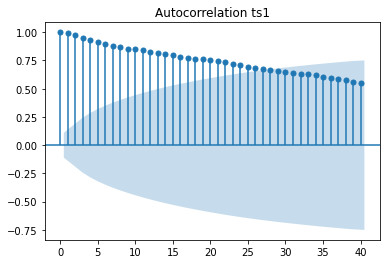

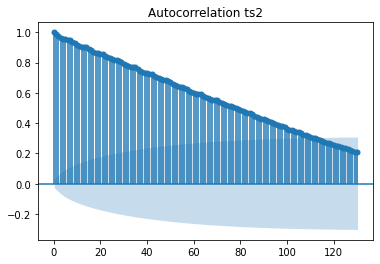

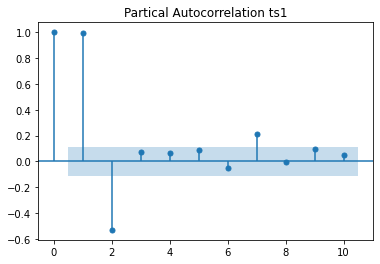

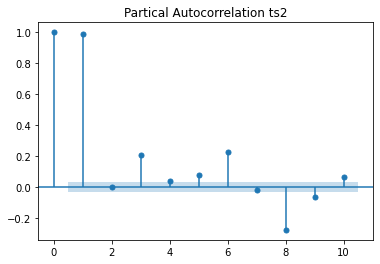

In [10]:
# посчитайте и нарисуйте график автокорреляционной функции
plot_acf(ts1_train["Dollars"], lags=40)
plt.title("Autocorrelation ts1")
plt.show()
plot_acf(ts2_train["Megawatts"], lags=130)
plt.title("Autocorrelation ts2")
plt.show()
plot_pacf(ts1_train["Dollars"], lags=10)
plt.title("Partical Autocorrelation ts1")
plt.show()
plot_pacf(ts2_train["Megawatts"], lags=10)
plt.title("Partical Autocorrelation ts2")
plt.show()


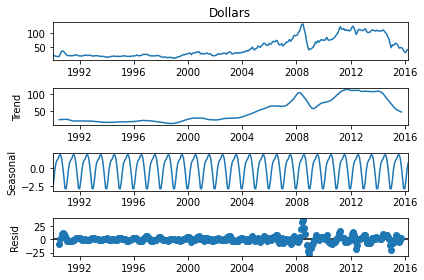

In [11]:
# разбейте временной ряд на повторяющиеся участки по длине сезонной составляющей и нарисуйте их наложенными
decomposition = seasonal_decompose(ts1_train["Dollars"], model="additive")
decomposition.plot()
plt.show()


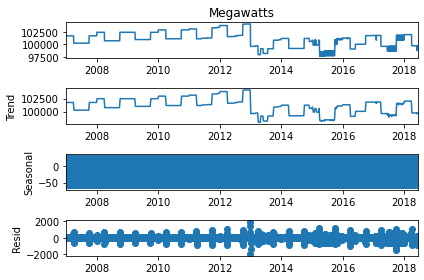

In [12]:
decomposition = seasonal_decompose(ts2_train["Megawatts"], model="additive")
decomposition.plot()
plt.show()


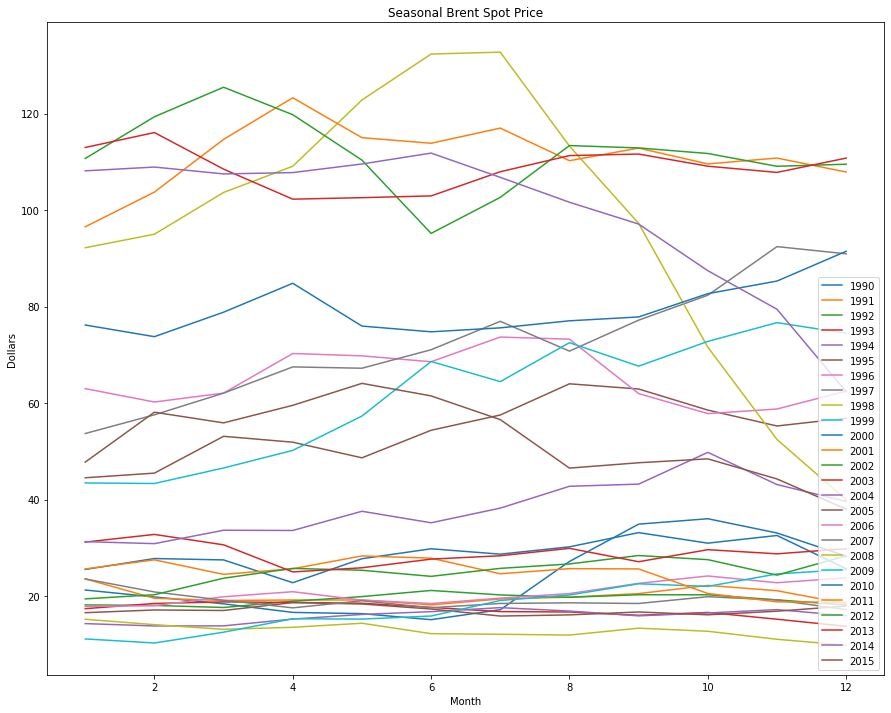

In [13]:
plt.figure(figsize=(15, 12))
period_1 = 12
for i in range(ts1_train.shape[0] // period_1):
    plt.plot(
        list(range(1, period_1 + 1)),
        ts1_train[period_1 * i : period_1 * (i + 1)]["Dollars"],
        label=1990 + i,
    )
plt.xlabel("Month")
plt.ylabel("Dollars")
plt.legend(loc=4)
plt.title("Seasonal Brent Spot Price")
plt.show()


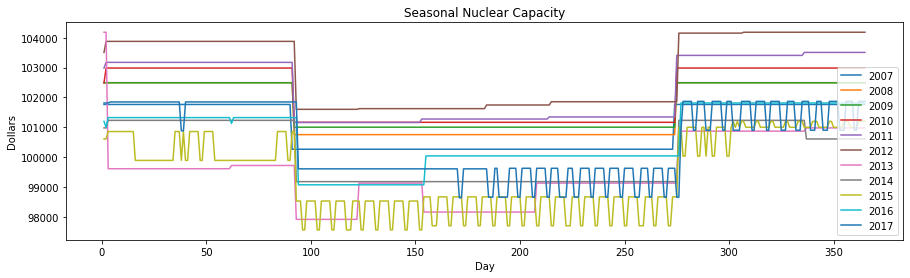

In [14]:
plt.figure(figsize=(15, 4))
period_1 = 365
for i in range(ts2_train.shape[0] // period_1):
    plt.plot(
        list(range(1, period_1 + 1)),
        ts2_train[period_1 * i : period_1 * (i + 1)]["Megawatts"],
        label=2007 + i,
    )
plt.xlabel("Day")
plt.ylabel("Dollars")
plt.legend(loc=4)
plt.title("Seasonal Nuclear Capacity")
plt.show()


## Задание 3. Предсказание месячного временного ряда (4 балла).

В этом задании Вам предстоит попробовать предсказать месячный временной ряд несколькими готовыми моделями со скользящим или растущим окном и выбрать среди них наилучшую.

В качестве метрики сравнения используйте MAE между истинными и предсказанными значениями ряда на тестовом отрезке.

### NaiveForecaster из sktime (1 балл).

Посчитайте предсказания следующими двумя наивными способами:

* $\hat{y}_{t+1} = y_{t}$
* $\hat{y}_{t+1} = y_{t-seasonality+1}$

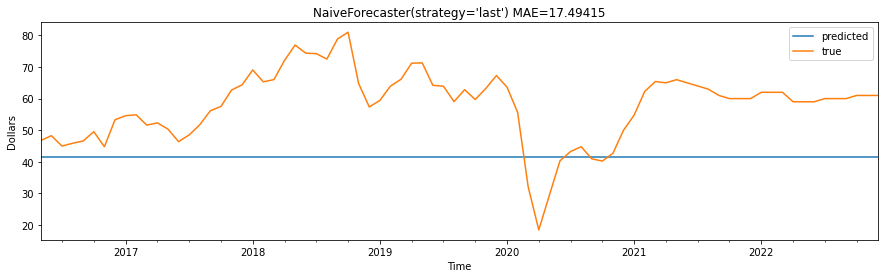

In [15]:
plt.figure(figsize=(15, 4))
model = NaiveForecaster(strategy="last")
model.fit(ts1_train.set_index(ts1_train.index.to_period("M")))
pred = model.predict(ts1_test.index.to_period("M"))
pred["Dollars"].plot(legend=False, label="predicted")
ts1_test["Dollars"].plot(label="true")
plt.xlabel("Time")
plt.ylabel("Dollars")
plt.legend()
plt.title(
    f"NaiveForecaster(strategy='last') MAE={mean_absolute_error(ts1_test['Dollars'], pred)}"
)
plt.show()


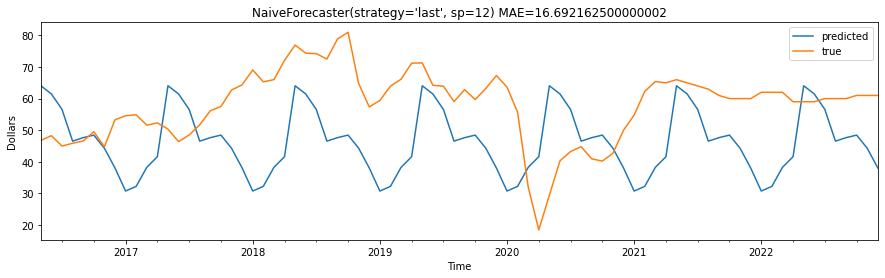

In [16]:
plt.figure(figsize=(15, 4))
model = NaiveForecaster(strategy="last", sp=12)
model.fit(ts1_train.set_index(ts1_train.index.to_period("M")))
pred = model.predict(ts1_test.index.to_period("M"))
pred["Dollars"].plot(legend=False, label="predicted")
ts1_test["Dollars"].plot(label="true")
plt.xlabel("Time")
plt.ylabel("Dollars")
plt.legend()
plt.title(
    f"NaiveForecaster(strategy='last', sp=12) MAE={mean_absolute_error(ts1_test['Dollars'], pred)}"
)
plt.show()


### ARIMA/AutoArima (1 балл).

Обучите из библиотеки `sktime` модели:

* SARIMA(1, 1, 1)(1, 0, 0)[12] (`ARIMA` в `sktime`)
* Алгоритм Хиндмана-Хандакара подбора SARIMA (`AutoARIMA` в `sktime`)

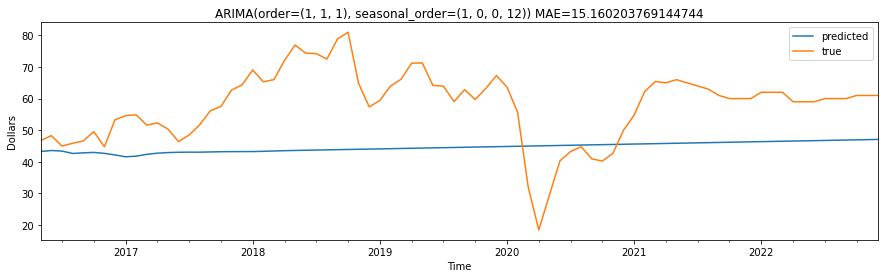

In [17]:
plt.figure(figsize=(15, 4))
model = ARIMA(order=(1, 1, 1), seasonal_order=(1, 0, 0, 12))
model.fit(ts1_train.set_index(ts1_train.index.to_period("M")))
pred = model.predict(ts1_test.index.to_period("M"))
pred["Dollars"].plot(legend=False, label="predicted")
ts1_test["Dollars"].plot(label="true")
plt.xlabel("Time")
plt.ylabel("Dollars")
plt.legend()
plt.title(
    f"ARIMA(order=(1, 1, 1), seasonal_order=(1, 0, 0, 12)) MAE={mean_absolute_error(ts1_test['Dollars'], pred)}"
)
plt.show()


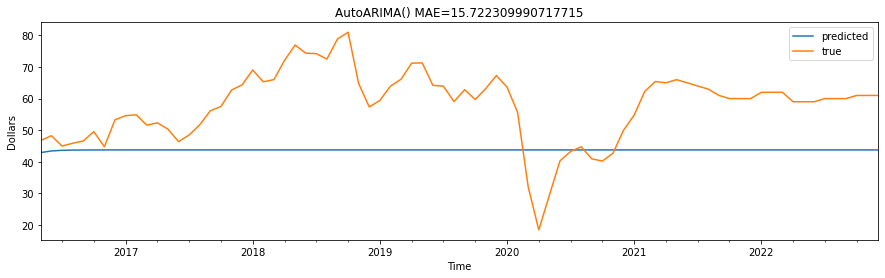

In [18]:
plt.figure(figsize=(15, 4))
model = AutoARIMA()
model.fit(ts1_train.set_index(ts1_train.index.to_period("M")))
pred = model.predict(ts1_test.index.to_period("M"))
pred["Dollars"].plot(legend=False, label="predicted")
ts1_test["Dollars"].plot(label="true")
plt.xlabel("Time")
plt.ylabel("Dollars")
plt.legend()
plt.title(f"AutoARIMA() MAE={mean_absolute_error(ts1_test['Dollars'], pred)}")
plt.show()


### LGT/DLT (1 балл).

Обучите из библиотеки `orbit` модели LGT и DLT

To run all diagnostics call pystan.check_hmc_diagnostics(fit)


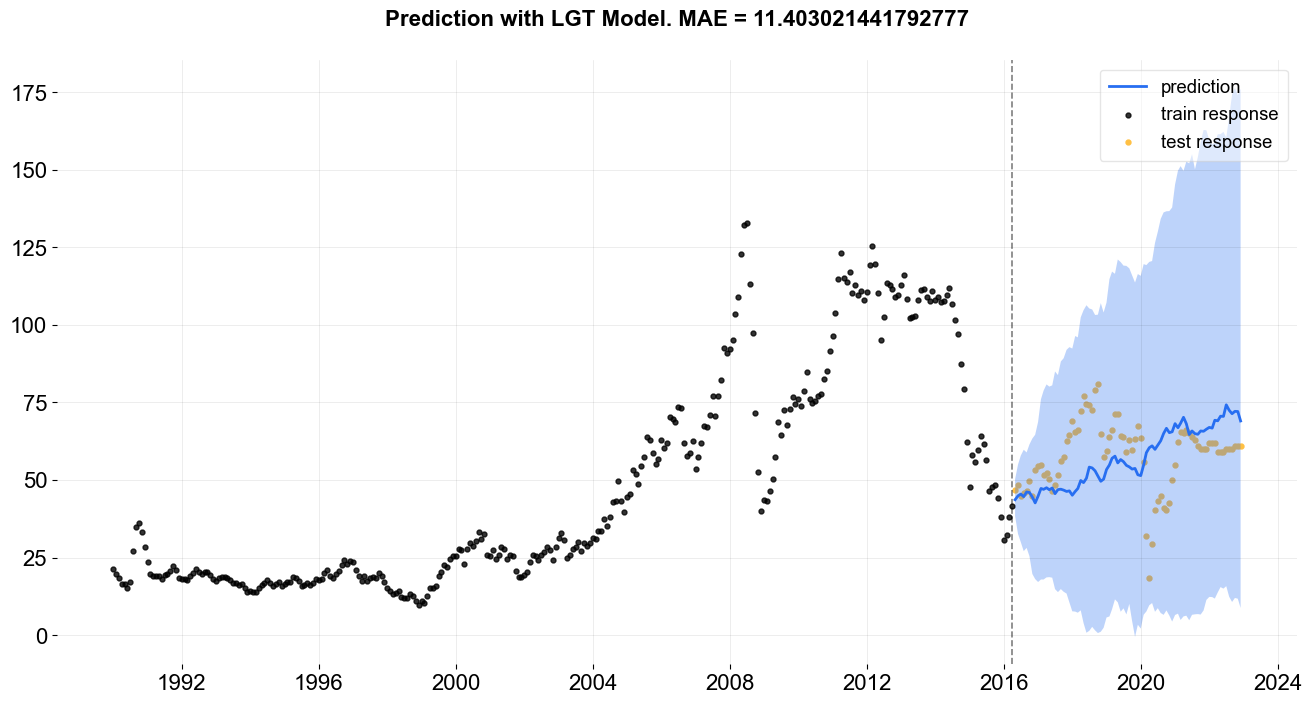

In [19]:
ts1_train["Time"] = ts1_train.index
ts1_test["Time"] = ts1_test.index
model = LGT(response_col="Dollars", date_col="Time", seasonality=12)

model.fit(df=ts1_train)
pred = model.predict(ts1_test)
plot_predicted_data(
    training_actual_df=ts1_train,
    predicted_df=pred,
    date_col="Time",
    actual_col="Dollars",
    test_actual_df=ts1_test,
    title=f"Prediction with LGT Model. MAE = {mean_absolute_error(ts1_test['Dollars'], pred['prediction'])}",
)
plt.show()


To run all diagnostics call pystan.check_hmc_diagnostics(fit)


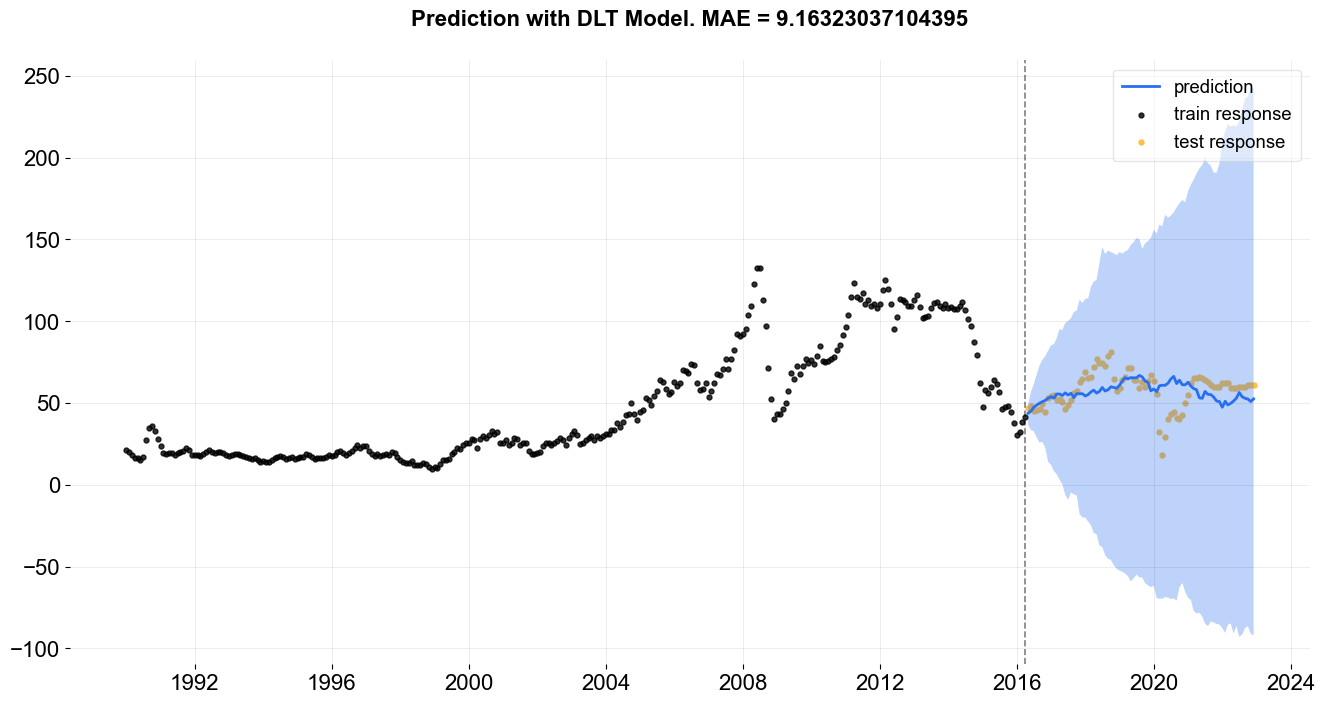

In [20]:
ts1_train["Time"] = ts1_train.index
ts1_test["Time"] = ts1_test.index
model = DLT(response_col="Dollars", date_col="Time", seasonality=12)

model.fit(df=ts1_train)
pred = model.predict(ts1_test)
plot_predicted_data(
    training_actual_df=ts1_train,
    predicted_df=pred,
    date_col="Time",
    actual_col="Dollars",
    test_actual_df=ts1_test,
    title=f"Prediction with DLT Model. MAE = {mean_absolute_error(ts1_test['Dollars'], pred['prediction'])}",
)
plt.show()


### ETS (1 балл).

Обучите из библиотеки `sktime` модели:

* ETS(AAA) (`ExponentialSmoothing` в `sktime`)
* ETS с автоматическим выбором по AIC (`AutoETS` в `sktime`)

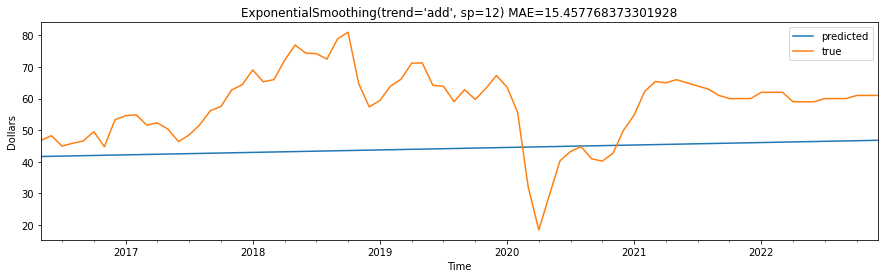

In [21]:
ts1_train.drop("Time", axis=1, inplace=True)
ts1_test.drop("Time", axis=1, inplace=True)
plt.figure(figsize=(15, 4))
model = ExponentialSmoothing(trend="add", sp=12)
model.fit(ts1_train.set_index(ts1_train.index.to_period("M")))
pred = model.predict(ts1_test.index.to_period("M"))
pred["Dollars"].plot(legend=False, label="predicted")
ts1_test["Dollars"].plot(label="true")
plt.xlabel("Time")
plt.ylabel("Dollars")
plt.legend()
plt.title(
    f"ExponentialSmoothing(trend='add', sp=12) MAE={mean_absolute_error(ts1_test['Dollars'], pred)}"
)
plt.show()


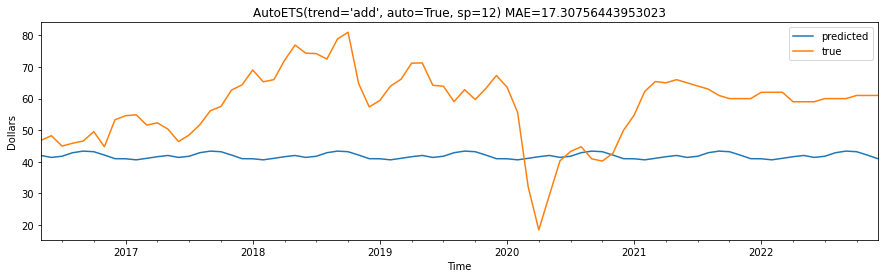

In [22]:
plt.figure(figsize=(15, 4))
model = AutoETS(trend="add", auto=True, sp=12)
model.fit(ts1_train.set_index(ts1_train.index.to_period("M")))
pred = model.predict(ts1_test.index.to_period("M"))
pred["Dollars"].plot(legend=False, label="predicted")
ts1_test["Dollars"].plot(label="true")
plt.xlabel("Time")
plt.ylabel("Dollars")
plt.legend()
plt.title(
    f"AutoETS(trend='add', auto=True, sp=12) MAE={mean_absolute_error(ts1_test['Dollars'], pred)}"
)
plt.show()


Нарисуйте для наилучшей модели предсказания с доверительным интервалом (если модель выдает его) и наложите их на истинные значения. В `sktime` `ETS` модель пока ещё не выдаёт доверительные интервалы, но при желании до них можно дотянуться :)

In [23]:
# Лучшая модель DLS из orbit с MAE=9.16. График нарисован выше


## Задание 4. Предсказание дневного временного ряда (3 балла).

В этом задании Вам предстоит попробовать предсказать выбранный Вами дневной временной ряд.

Аналогично, в качестве метрики используем MAE.



### NaiveForecaster из sktime (1 балл).

Посчитайте предсказания следующими двумя наивными способами:

* $\hat{y}_{t+1} = y_{t}$
* $\hat{y}_{t+1} = y_{t-seasonality+1}$

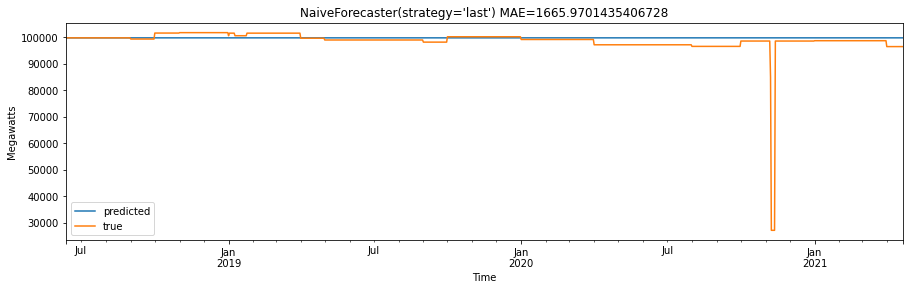

In [24]:
plt.figure(figsize=(15, 4))
model = NaiveForecaster(strategy="last")
model.fit(ts2_train.set_index(ts2_train.index.to_period("D")))
pred = model.predict(ts2_test.index.to_period("D"))
pred["Megawatts"].plot(legend=False, label="predicted")
ts2_test["Megawatts"].plot(label="true")
plt.xlabel("Time")
plt.ylabel("Megawatts")
plt.legend()
plt.title(
    f"NaiveForecaster(strategy='last') MAE={mean_absolute_error(ts2_test['Megawatts'], pred)}"
)
plt.show()


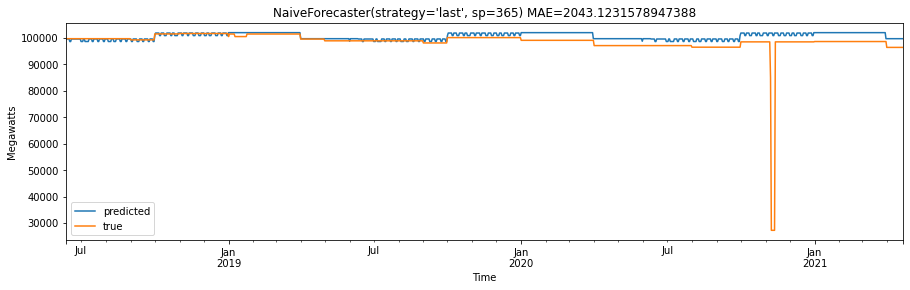

In [25]:
plt.figure(figsize=(15, 4))
model = NaiveForecaster(strategy="last", sp=365)
model.fit(ts2_train.set_index(ts2_train.index.to_period("D")))
pred = model.predict(ts2_test.index.to_period("D"))
pred["Megawatts"].plot(legend=False, label="predicted")
ts2_test["Megawatts"].plot(label="true")
plt.xlabel("Time")
plt.ylabel("Megawatts")
plt.legend()
plt.title(
    f"NaiveForecaster(strategy='last', sp=365) MAE={mean_absolute_error(ts2_test['Megawatts'], pred)}"
)
plt.show()


### KTR из orbit (1 балл).



INFO:root:Guessed max_plate_nesting = 1


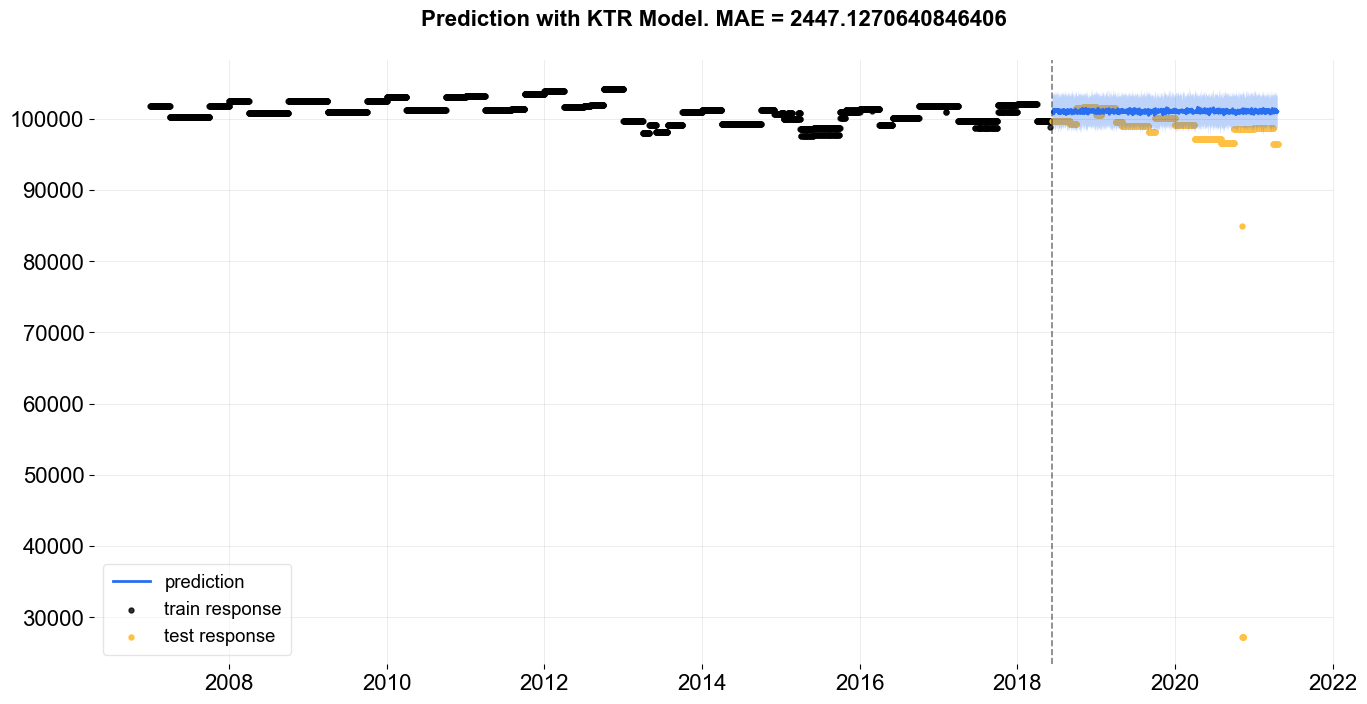

In [26]:
ts2_train["Time"] = ts2_train.index
ts2_test["Time"] = ts2_test.index
model = KTR(response_col="Megawatts", date_col="Time", seasonality=365)

model.fit(df=ts2_train)
pred = model.predict(ts2_test)
plot_predicted_data(
    training_actual_df=ts2_train,
    predicted_df=pred,
    date_col="Time",
    actual_col="Megawatts",
    test_actual_df=ts2_test,
    title=f"Prediction with KTR Model. MAE = {mean_absolute_error(ts2_test['Megawatts'], pred['prediction'])}",
)
plt.show()


### Phophet (1 балл).



INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


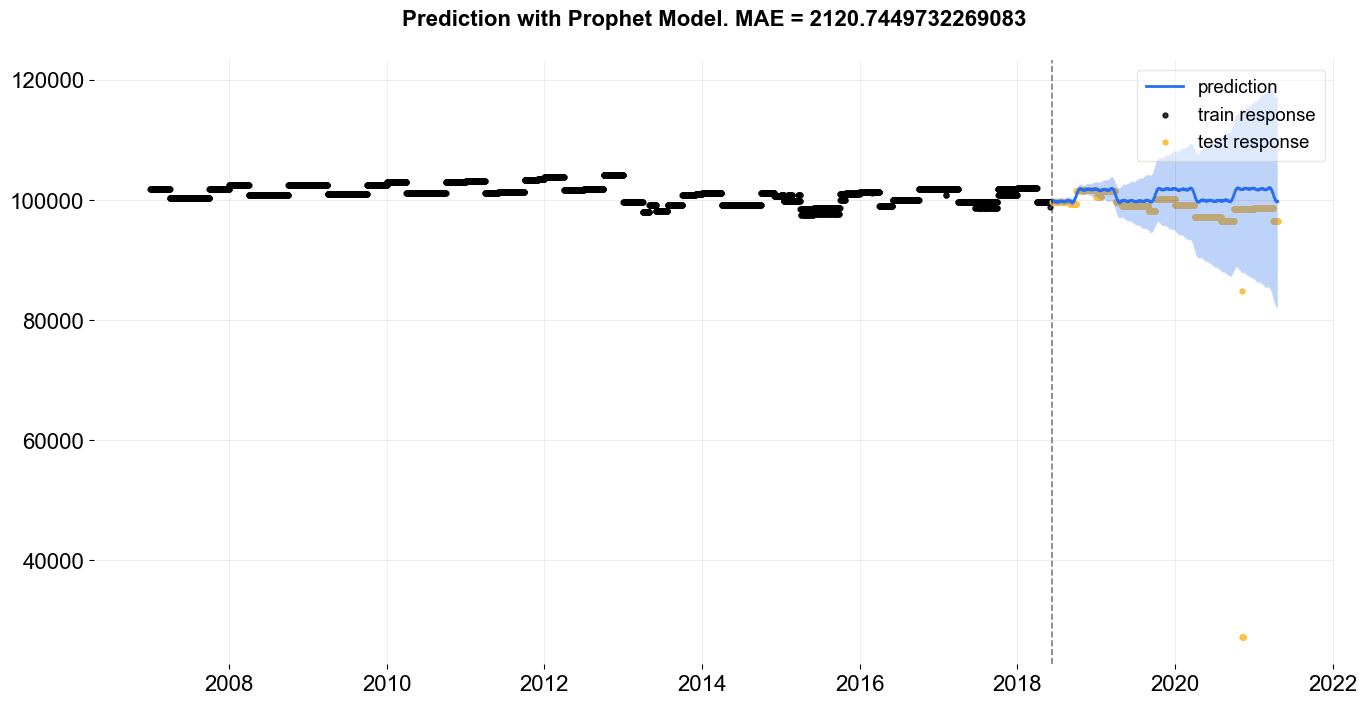

In [27]:
ts2_train.columns = ["y", "ds"]
ts2_test.columns = ["y", "ds"]
model = Prophet(yearly_seasonality=True)
model.fit(ts2_train)
pred = model.predict(ts2_test)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
pred.columns = ["ds", "prediction", "prediction_5", "prediction_95"]
ts2_train.columns = ["prediction", "ds"]
ts2_test.columns = ["prediction", "ds"]
plot_predicted_data(
    training_actual_df=ts2_train,
    predicted_df=pred,
    date_col="ds",
    actual_col="prediction",
    test_actual_df=ts2_test,
    title=f"Prediction with Prophet Model. MAE = {mean_absolute_error(ts2_test['prediction'], pred['prediction'])}",
)
plt.show()


Нарисуйте для наилучшей модели предсказания с доверительным интервалом (если модель выдает его) и наложите их на истинные значения.

In [28]:
# Самый лучший NaiveForecaster(strategy="last") с MAE=1665. График выше


## Задание 5. Предсказание временного ряда моделями машинного обучения (1 балл).

Возьмите один из ваших рядов, сформируйте по нему матрицу объект-признак и целевой вектор.

Разбейте данные на train/test в той же пропорции, что разбивали в заданиях выше.

Обучите различные классические модели машинного обучения и оцените их качество (MAE). 

Какая из моделей справилась с задачей предсказания лучше всего?

In [29]:
# обучите классические модели ML
X_train = (ts1_train.index - ts1_train.index[0]).days.to_numpy().reshape(-1, 1)
y_train = ts1_train["Dollars"].to_numpy()
X_test = (ts1_test.index - ts1_train.index[0]).days.to_numpy().reshape(-1, 1)
y_test = ts1_test["Dollars"].to_numpy()


In [30]:
clf = LinearRegression().fit(X_train, y_train)
pred = clf.predict(X_test)
mean_absolute_error(y_test, pred)


49.88413638510674

In [31]:
clf = GradientBoostingRegressor().fit(X_train, y_train)
pred = clf.predict(X_test)
mean_absolute_error(y_test, pred)


18.78637294191342

In [32]:
clf = SVR().fit(X_train, y_train)
pred = clf.predict(X_test)
mean_absolute_error(y_test, pred)


12.938407725739989

In [33]:
clf = KNeighborsRegressor().fit(X_train, y_train)
pred = clf.predict(X_test)
mean_absolute_error(y_test, pred)


22.448150000000005

In [34]:
clf = LinearSVR().fit(X_train, y_train)
pred = clf.predict(X_test)
mean_absolute_error(y_test, pred)


15.542843532939974

In [35]:
clf = RandomForestRegressor().fit(X_train, y_train)
pred = clf.predict(X_test)
mean_absolute_error(y_test, pred)


19.77858149999998

In [36]:
clf = DecisionTreeRegressor().fit(X_train, y_train)
pred = clf.predict(X_test)
mean_absolute_error(y_test, pred)


17.49415

In [37]:
clf = Ridge().fit(X_train, y_train)
pred = clf.predict(X_test)
mean_absolute_error(y_test, pred)


49.88413636040784

In [38]:
# Лучше всего справилась SVR() c MAE=12.9


## Бонус. Напишите свою модель на STAN (3 балла).

Разработайте и испытайте свою модель для месячного ряда в STAN.

Сравните качество прогнозов с наивной сезонной моделью на тестовой выборке с помощью MAE. 

Комментарий: итоговый балл за домашнее задание ставится по формуле минимум(10, ваш суммарный балл за задания).

In [39]:
# ваш код модели на STAN и её обучения здесь


In [40]:
# посчитайте метрики на test


In [41]:
# нарисуйте предсказания
